# Procesamiento de datasets: Salud mental en el area de la tecnologia

Este dataset registra una serie de respuestas que se dio en una encuesta sobre actitudes hacia la salud mental y la prevalencia de trastornos mentales entre trabajadores de la industria de la tecnología. Abarca desde las percepciones sobre historial familiar, tratamiento buscado, interferencia de la condición de trabajo hasta el clima organizacional.

También cubre áreas como beneficios, anonimato, facilidad para pedir permiso, consecuencias percibidas de hablar del tema con supervisores o colegas del trabajo.

Esta práctica consiste en realizar cinco distintas técnicas de procesamiento de datasets para la mejora en la lectura de los datos y poder tomar decisiones más acordes a lo que realmente se nos está presentando con esta información.

La encuesta fue publicada por OSMI (Open Sourcing Mental Illness), una organización sin fines de lucro dedicada a la salud mental en el área de la tecnología, como parte de su encuesta anual "Mental Health in Tech Survey". Es una encuesta de autoselección, distribuida en línea y difundida principalmente en la comunidad Tech.

Cada fila es la respuesta de una persona de manera individual que trabaja o trabajó en o cerca de la industria tecnológica al momento de responder la encuesta. No es una única empresa ni un único país, fue un encuestado totalmente autoseleccionado.

Se aplican las siguientes cinco técnicas y en cada una se grafica antes y después:

1. Limpieza de datos
2. Aumento de datos
3. Extracción de características
4. Reducción de dimensionalidad
5. Selección de características

Antes se hace el análisis exploratorio (EDA).



# Analisis exploratorio (EDA)

Primero comenzaramos con la limpieza del dataset, para esto realizamos una exploracion de los datos, verificando que tengan la estructura adecuada, despues continuaremos con la verificacion de elementos duplicados, datos irreales, elementos vacios, etc.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import resample


In [34]:
df = pd.read_csv('survey.csv')
if df.shape[0] == 0:
    print('Advertencia: El archivo esta vacio.')
n_filas = df.shape[0]
n_columnas = df.shape[1]
print(f'Número de filas: {n_filas}')
print(f'Número de columnas: {n_columnas}')
columnas_esperadas = 27
cumple_columnas = (n_columnas == columnas_esperadas)
print(f'¿Tiene exactamente {columnas_esperadas} columnas?: {cumple_columnas}')
age_es_numerico = pd.api.types.is_integer_dtype(df['Age'])
print(f'¿La columna "Age" es numérica (entero)?: {age_es_numerico}')
timestamp_es_texto = (df['Timestamp'].dtype == object)
print(f'¿La columna "Timestamp" es texto?: {timestamp_es_texto}')
sin_columnas_vacias = (df.isna().mean() < 1.0).all()
print(f'¿El dataset no tiene columnas completamente vacias?: {sin_columnas_vacias}')

print("Edades menores a 18 o mayores a 65:")
print(sorted(df[(df["Age"] < 18) | (df["Age"] > 65)]["Age"].tolist()))

Número de filas: 1259
Número de columnas: 27
¿Tiene exactamente 27 columnas?: True
¿La columna "Age" es numérica (entero)?: True
¿La columna "Timestamp" es texto?: False
¿El dataset no tiene columnas completamente vacias?: True
Edades menores a 18 o mayores a 65:
[-1726, -29, -1, 5, 8, 11, 72, 329, 99999999999]


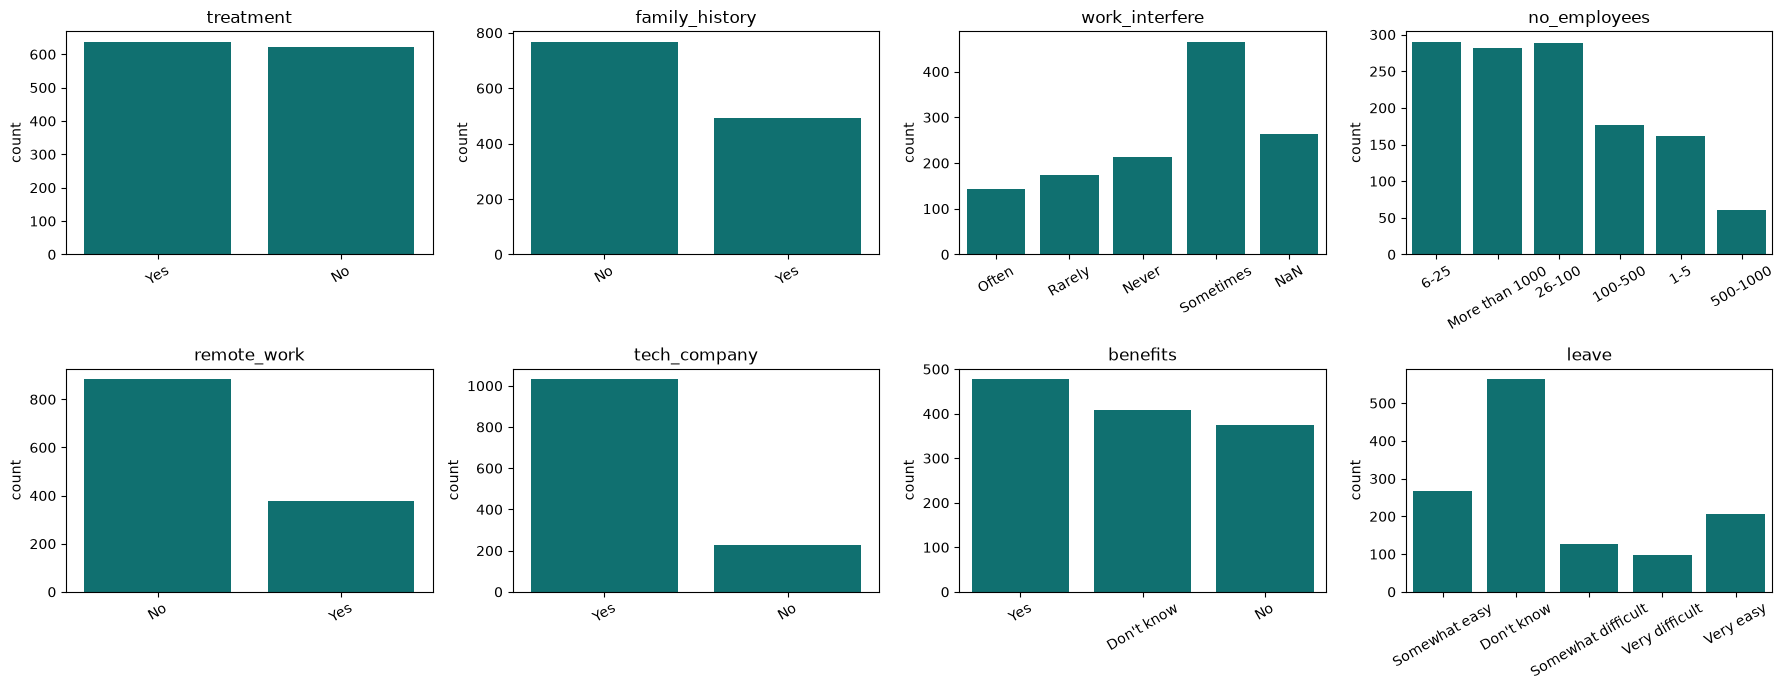

In [35]:
variables = ["treatment", "family_history", "work_interfere", "no_employees",
             "remote_work", "tech_company", "benefits", "leave"]

fig, ejes = plt.subplots(2, 4, figsize=(18, 7))
ejes = ejes.ravel()
for i in range(len(variables)):
    col = variables[i]
    sns.countplot(x=df[col].fillna("NaN"), ax=ejes[i], color="Teal")
    ejes[i].set_title(col)
    ejes[i].set_xlabel("")
    ejes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Porcentaje de personas con treatment igual a Yes en cada categoría

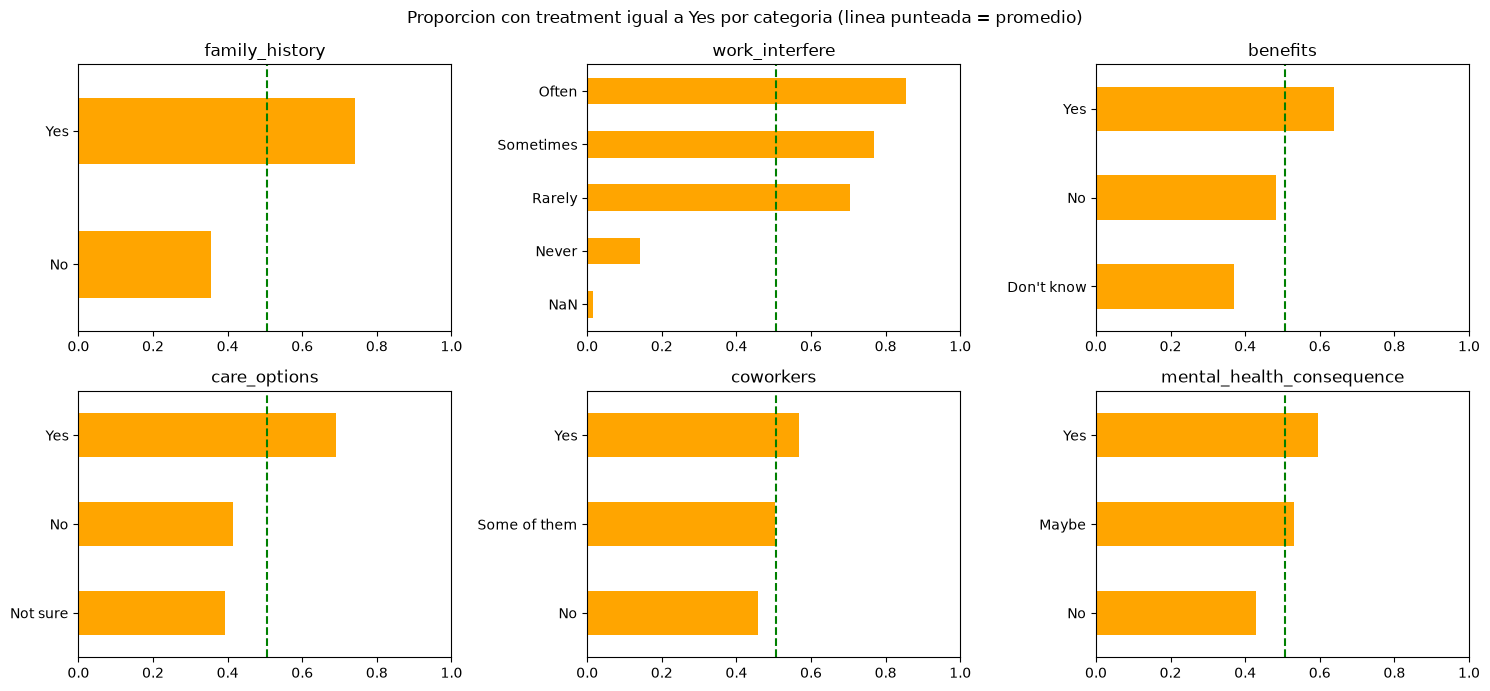

In [36]:

variables = ["family_history", "work_interfere", "benefits", "care_options", "coworkers", "mental_health_consequence"]
tratamiento_si = (df["treatment"] == "Yes")

fig, ejes = plt.subplots(2, 3, figsize=(15, 7))
ejes = ejes.ravel()
for i in range(len(variables)):
    col = variables[i]
    tasa = tratamiento_si.groupby(df[col].fillna("NaN")).mean().sort_values()
    tasa.plot.barh(ax=ejes[i], color="Orange")
    ejes[i].set_title(col)
    ejes[i].set_xlim(0, 1)
    ejes[i].set_ylabel("")
    ejes[i].axvline(0.506, linestyle="--", color="Green")  
plt.suptitle("Proporcion con treatment igual a Yes por categoria (linea punteada = promedio)")
plt.tight_layout()
plt.show()

### Atributos con relacion con la variable Treatment

Ahora veremos que variables estan relaciones con el atributo de Treatment = Yes, esto con la intencion de ver en que variables las personas que estan en tratamiento aparecen mas recurrente.

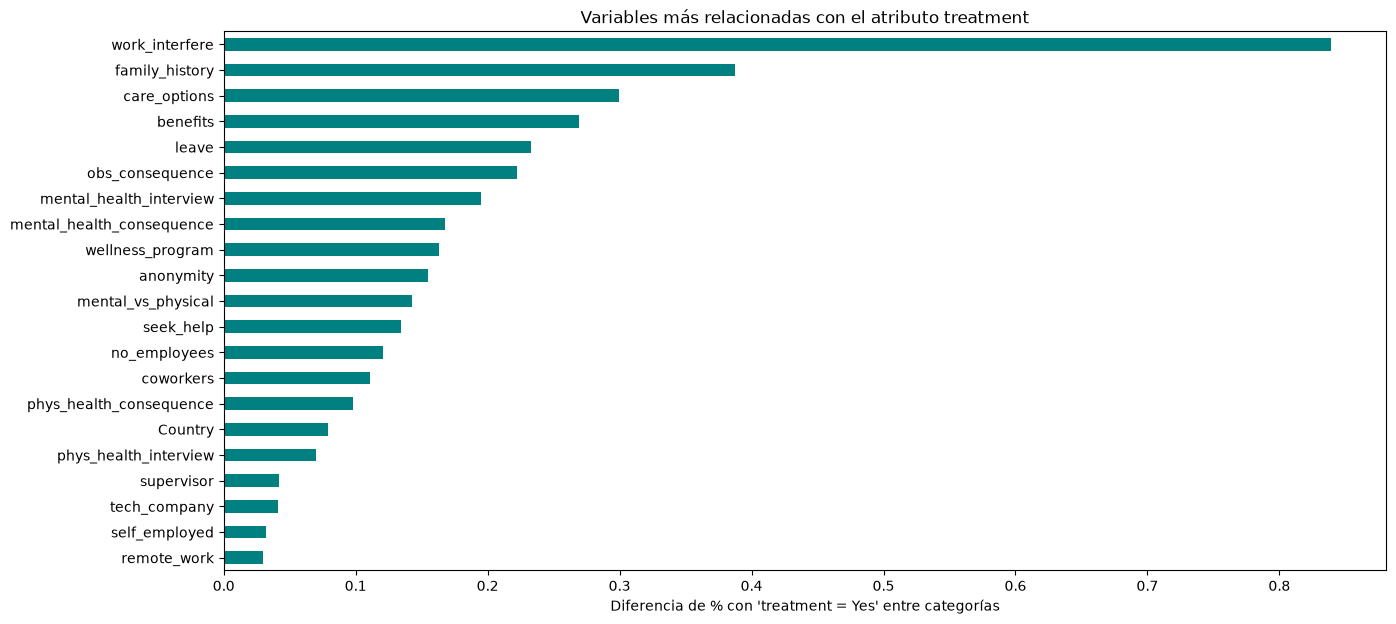

In [37]:
columnas = []
for c in df.columns:
    if c not in ["Timestamp", "Age", "Gender", "state", "comments", "treatment"]:
        columnas.append(c)

tratamiento_si = (df["treatment"] == "Yes")

diferencias = []
for c in columnas:
    datos_col = df[c].fillna("NaN")
    tasa = tratamiento_si.groupby(datos_col).mean()   
    cantidad = datos_col.value_counts()                 
    tasa = tasa[cantidad[tasa.index] >= 30]           
    diferencias.append(tasa.max() - tasa.min())

relacion = pd.Series(diferencias, index=columnas).sort_values()

relacion.plot.barh(figsize=(15,7), color="Teal")
plt.xlabel("Diferencia de % con 'treatment = Yes' entre categorías")
plt.title("Variables más relacionadas con el atributo treatment")
plt.show()

### Conclusiones del EDA
- `treatment` esta balanceado (50%/50%).
- Las variables más relacionadas con el tratamiento son `work_interfere`, `family_history`, `care_options` y `benefits`.
- Problemas de calidad: `Age` tiene valores imposibles (negativos, 5, 329, 99999999999), `Gender` tiene 49 formas de escribirse, y hay nulos en `state`, `work_interfere`, `self_employed` y `comments`. En `comments` es normal que sean nulos, pues es un atributo opcional en la encuesta.
- `Gender` esta muy desbalanceado (~79 % hombres), esto es importante para el aumento de datos.
- El atributo `work_interfere` solo se pregunta a personas que ya tienen una condicion, asi que esto ocasiona que este muy ligada a `treatment`.

# 1. Limpieza de datos

Los datos vienen de un formulario donde la edad y el genero se escribian a mano, asi que hay errores que si no se arreglan, la variable `Age` arruinaria cualquier promedio y el atributo `Gender` crearia decenas de categorias inconsistentes.


Plan de Limpieza y Preprocesamiento de Datos.

Tratamiento de Age: Los registros fuera del rango de 18 a 65 años se consideran valores imposibles y se reemplazan por la mediana, garantizando un ajuste robusto que no se vea alterado por valores atipicos (outliers).

Estandarización de Gender: Dado que presenta 49 variantes distintas este atributo, se agrupan en tres categorías principales (Hombre, Mujer y Otros) para eliminar categorías irrelevantes con un solo registro.

Imputación de work_interfere: Los valores nulos no se eliminan; se imputan como "No aplica", ya que representan a personas que no padecen una condición médica y, por lo tanto, aportan información relevante.

Imputación de self_employed: Al ser únicamente 18 registros faltantes dentro de una categoría abrumadoramente mayoritaria, se imputan utilizando la moda ("No").

Consolidación de Country: De los 48 países registrados, se conservan los 5 principales con mayor frecuencia y los demás se reagrupan bajo la categoría "Other" para evitar la dispersión por países con muy pocos datos.

Eliminación de columnas (Timestamp, comments, state): Se descartan Timestamp por actuar solo como identificador, comments por ser texto libre no estructurado (con un 87 % de datos nulos) y state por ser información redundante respecto al país.

In [38]:
# Esto es para comparar el antes/despues
df_original = df.copy()       
df_limpio = df.copy()

edades_malas = (df_limpio["Age"] < 18) | (df_limpio["Age"] > 65)
mediana = df_limpio[~edades_malas]["Age"].median()
print("Edades inválidas encontradas:", edades_malas.sum())
df_limpio.loc[edades_malas, "Age"] = mediana


hombres = ["male", "m", "make", "man", "cis male", "cis man", "male (cis)", "mal", "maile",
           "msle", "mail", "malr", "guy (-ish) ^_^", "male-ish", "ostensibly male, unsure what that really means"]
mujeres = ["female", "f", "woman", "femake", "female (cis)", "cis female", "cis-female/femme",
           "femail", "female (trans)", "trans woman", "trans-female"]

def limpiar_genero(g):
    g = str(g).strip().lower()
    if g in hombres:
        return "Male"
    elif g in mujeres:
        return "Female"
    else:
        return "Other"

df_limpio["Gender"] = df_limpio["Gender"].apply(limpiar_genero)

df_limpio["work_interfere"] = df_limpio["work_interfere"].fillna("No aplica")
df_limpio["self_employed"] = df_limpio["self_employed"].fillna("No")

top5 = df_limpio["Country"].value_counts().head(5).index
df_limpio.loc[~df_limpio["Country"].isin(top5), "Country"] = "Other"

df_limpio = df_limpio.drop(columns=["Timestamp", "comments", "state"])

print("Cantidad de filas y atributos antes de la limpieza:", df_original.shape)
print("Cantidad de filas y atributos despues de la limpieza", df_limpio.shape)
print("Nulos que quedan:", df_limpio.isna().sum().sum())

Edades inválidas encontradas: 9
Cantidad de filas y atributos antes de la limpieza: (1259, 27)
Cantidad de filas y atributos despues de la limpieza (1259, 24)
Nulos que quedan: 0


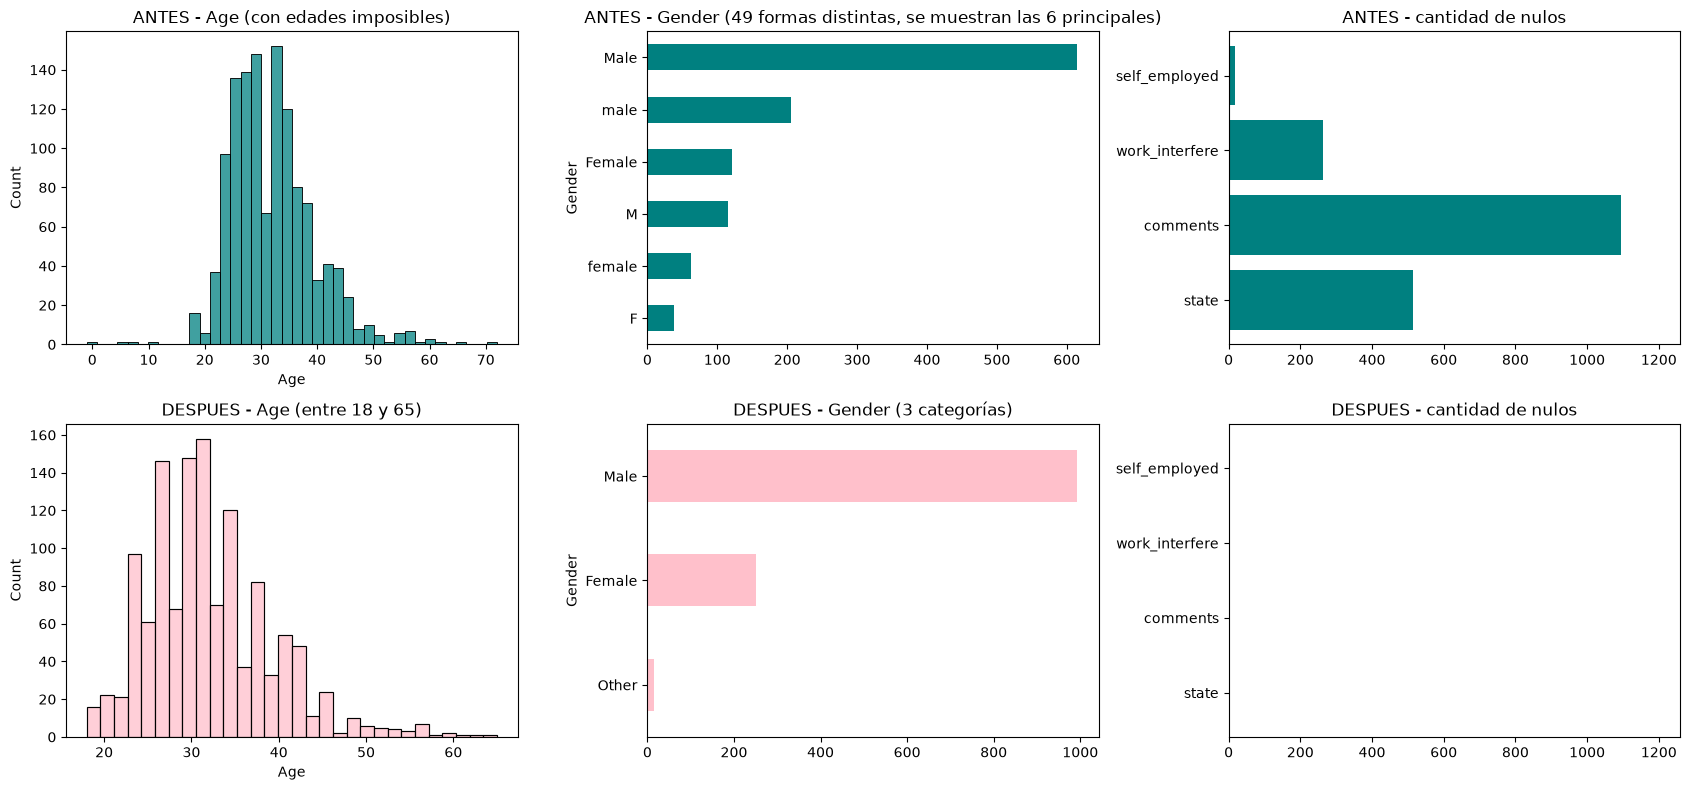

In [39]:
fig, ejes = plt.subplots(2, 3, figsize=(17, 8))

sns.histplot(df_original[(df_original["Age"] > -5) & (df_original["Age"] < 100)]["Age"], bins=40, ax=ejes[0, 0], color="Teal")
ejes[0, 0].set_title("ANTES - Age (con edades imposibles)")
sns.histplot(df_limpio["Age"], bins=30, ax=ejes[1, 0], color="Pink")
ejes[1, 0].set_title("DESPUES - Age (entre 18 y 65)")

generos_antes = df_original["Gender"].value_counts().head(6)
generos_antes.plot.barh(ax=ejes[0, 1], color="Teal")
ejes[0, 1].invert_yaxis()
ejes[0, 1].set_title("ANTES - Gender (49 formas distintas, se muestran las 6 principales)")
df_limpio["Gender"].value_counts().plot.barh(ax=ejes[1, 1], color="Pink")
ejes[1, 1].invert_yaxis()
ejes[1, 1].set_title("DESPUES - Gender (3 categorías)")

cols_nulos = ["state", "comments", "work_interfere", "self_employed"]
nulos_antes = []
nulos_despues = []
for c in cols_nulos:
    nulos_antes.append(df_original[c].isna().sum())
    if c in df_limpio.columns:
        nulos_despues.append(df_limpio[c].isna().sum())
    else:
        nulos_despues.append(0)         

ejes[0, 2].barh(cols_nulos, nulos_antes, color="Teal")
ejes[0, 2].set_title("ANTES - cantidad de nulos")
ejes[1, 2].barh(cols_nulos, nulos_despues, color="Pink")
ejes[1, 2].set_title("DESPUES - cantidad de nulos")
ejes[1, 2].set_xlim(0, 1259)
ejes[0, 2].set_xlim(0, 1259)
plt.tight_layout()
plt.show()


La variable `Age` paso de un promedio absurdo (79 millones) a unos 32 años, `Gender` paso de 49 categorías a 3, y ya no hay nulos. Desde aqui se usa `df_limpio` para las siguientes tecnicas.

# 2. Aumento de datos

El atributo `treatment` esta balanceado, pero `Gender` no lo esta: 79 % hombres, 20 % mujeres y solo 15 personas en "Other". Un modelo aprende sobre todo el patron de los hombres y puede funcionar peor con los demas grupos.

Como los datos son de tabla (casi todo categorico), no se pueden usar tecnicas como girar imagenes.Hago un sobremuestreo con ruido: tomo filas al azar de los grupos pequeños (`Female` y `Other`), las copio y a las copias les cambio un poco la edad (entre -2 y +2 años) para que no sean copias identicas.

In [40]:
def aumentar(datos):
    n_hombres = (datos["Gender"] == "Male").sum()
    mujeres = datos[datos["Gender"] == "Female"]
    otros = datos[datos["Gender"] == "Other"]

    meta_mujeres = int(n_hombres * 0.5)    
    meta_otros = int(n_hombres * 0.05)    

    nuevas_mujeres = resample(mujeres, replace=True, n_samples=meta_mujeres - len(mujeres), random_state=42)
    nuevos_otros = resample(otros, replace=True, n_samples=meta_otros - len(otros), random_state=42)

    for nuevas in [nuevas_mujeres, nuevos_otros]:
        ruido = np.random.randint(-2, 3, size=len(nuevas))
        nuevas["Age"] = (nuevas["Age"] + ruido).clip(lower=18)

    return pd.concat([datos, nuevas_mujeres, nuevos_otros], ignore_index=True)

np.random.seed(42)
df_aumentado = aumentar(df_limpio)

print("ANTES:")
print(df_limpio["Gender"].value_counts())
print()
print("DESPUES:")
print(df_aumentado["Gender"].value_counts())

ANTES:
Gender
Male      993
Female    251
Other      15
Name: count, dtype: int64

DESPUES:
Gender
Male      993
Female    496
Other      49
Name: count, dtype: int64


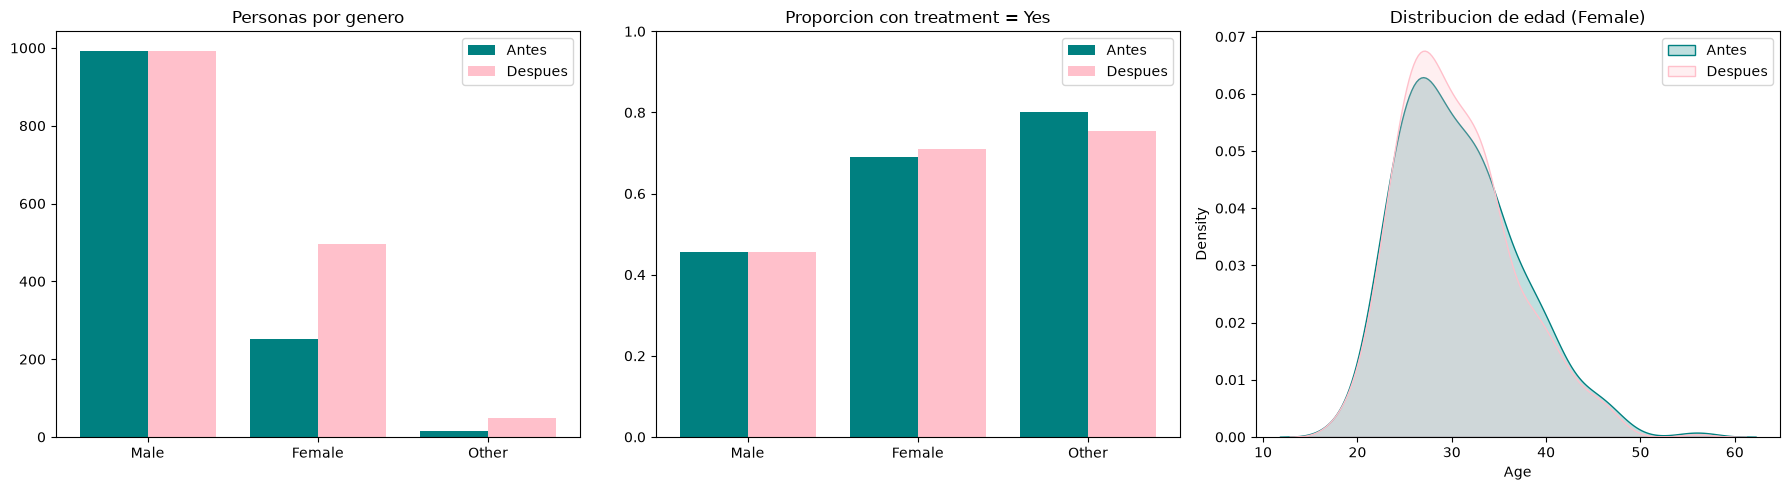

In [41]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

orden = ["Male", "Female", "Other"]
antes = df_limpio["Gender"].value_counts()[orden]
despues = df_aumentado["Gender"].value_counts()[orden]
posicion = np.arange(3)
ejes[0].bar(posicion - 0.2, antes.values, width=0.4, color="Teal", label="Antes")
ejes[0].bar(posicion + 0.2, despues.values, width=0.4, color="Pink", label="Despues")
ejes[0].set_xticks(posicion)
ejes[0].set_xticklabels(orden)
ejes[0].set_title("Personas por genero")
ejes[0].legend()

tasa_antes = (df_limpio["treatment"] == "Yes").groupby(df_limpio["Gender"]).mean()[orden]
tasa_despues = (df_aumentado["treatment"] == "Yes").groupby(df_aumentado["Gender"]).mean()[orden]
ejes[1].bar(posicion - 0.2, tasa_antes.values, width=0.4, color="Teal", label="Antes")
ejes[1].bar(posicion + 0.2, tasa_despues.values, width=0.4, color="Pink", label="Despues")
ejes[1].set_xticks(posicion)
ejes[1].set_xticklabels(orden)
ejes[1].set_ylim(0, 1)
ejes[1].set_title("Proporcion con treatment = Yes")
ejes[1].legend()

sns.kdeplot(df_limpio[df_limpio["Gender"] == "Female"]["Age"], ax=ejes[2], color="Teal", label="Antes", fill=True)
sns.kdeplot(df_aumentado[df_aumentado["Gender"] == "Female"]["Age"], ax=ejes[2], color="Pink", label="Despues", fill=True)
ejes[2].set_title("Distribucion de edad (Female)")
ejes[2].legend()

plt.tight_layout()
plt.show()

- La grafica "Personas por genero" ahora nos muestra que los grupos pequeños tienen mas peso.
- En grafica "Proporcion con treatment" el porcentaje con tratamiento casi no cambia en `Female`, en `Other` baja de 0.80 a 0.76, porque con solo 15 personas reales cualquier copia al azar mueve mucho el porcentaje (ese grupo es demasiado pequeño para sacar conclusiones).
- La grafica "Distribucion de edad (Female)" muestra la distribución de edades antes y despues, podemos notar que no hay una diferencia notoria en las edades de los datos generados.
- Para el resto de la practica uso `df_limpio` (sin copias) para no mezclar datos repetidos.

# 3. Extracción de características

Varias preguntas de la encuesta miden la misma idea (por ejemplo `benefits`, `care_options`, `wellness_program`, `seek_help` y `anonymity` miden "que tanto apoya la empresa la salud mental"). Cada una sola es ruidosa, si las resumo en un indice, obtengo una variable mas fácil de interpretar y con menos columnas.

In [42]:
df_feat = df_limpio.copy()

preguntas_apoyo = ["benefits", "care_options", "wellness_program", "seek_help", "anonymity"]
df_feat["support_score"] = (df_feat[preguntas_apoyo] == "Yes").sum(axis=1)

preguntas_politicas = preguntas_apoyo + ["leave", "mental_vs_physical"]
df_feat["awareness_gap"] = df_feat[preguntas_politicas].isin(["Don't know", "Not sure"]).sum(axis=1)

df_feat["age_group"] = pd.cut(df_feat["Age"], bins=[17, 25, 35, 45, 100],
                              labels=["18-25", "26-35", "36-45", "46+"]).astype(str)

nuevas = ["support_score", "awareness_gap", "age_group"]
print("Columnas antes:", df_limpio.shape[1], "| después:", df_feat.shape[1])
df_feat[nuevas].head()

Columnas antes: 24 | después: 27


,support_score,awareness_gap,age_group
0,3,1,36-45
1,0,6,36-45
2,0,1,26-35
3,1,0,26-35
4,1,5,26-35


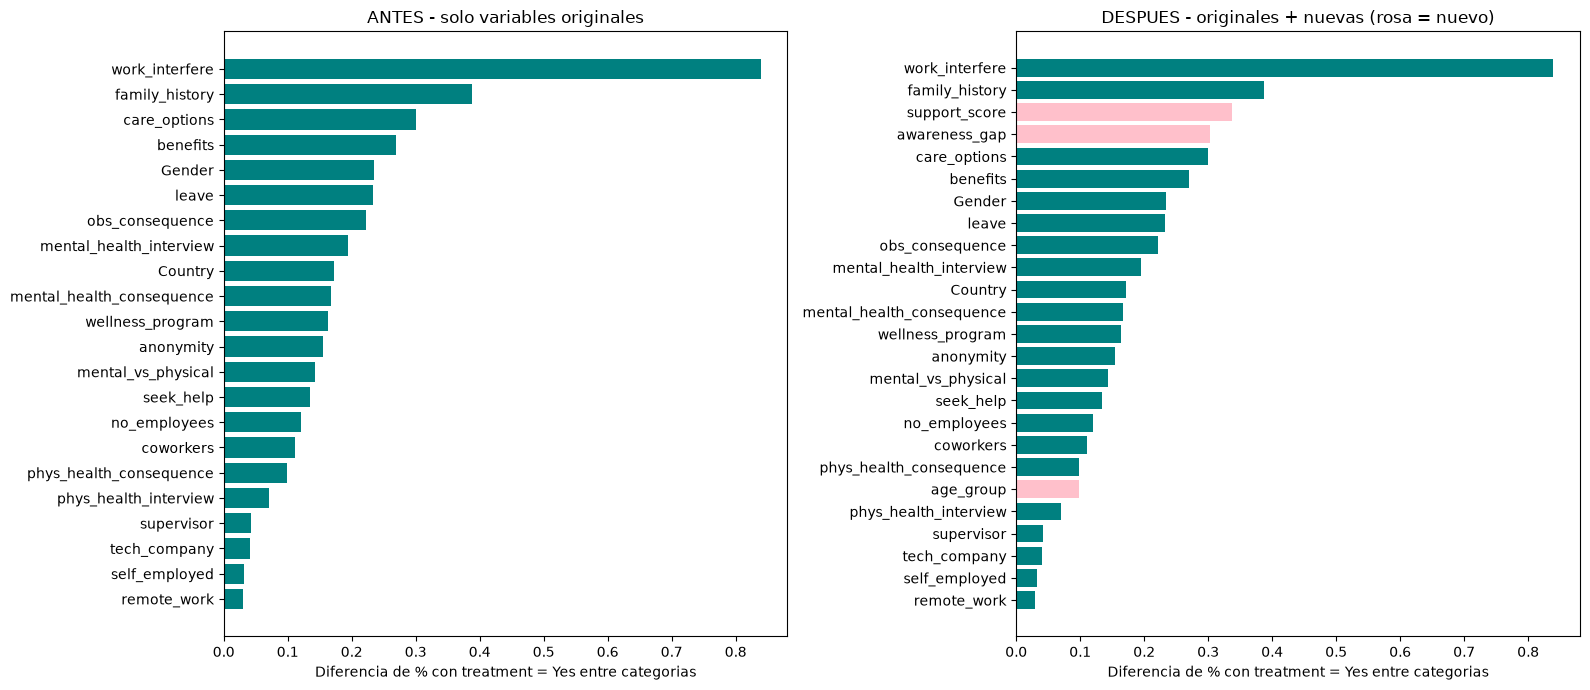

In [43]:
tratamiento_si = (df_feat["treatment"] == "Yes")
originales = []
for c in df_limpio.columns:
    if c not in ["Age", "treatment"]:
        originales.append(c)

todas = originales + nuevas     

diferencias = []
for c in todas:
    datos_col = df_feat[c].astype(str)
    tasa = tratamiento_si.groupby(datos_col).mean()     
    cantidad = datos_col.value_counts()                
    tasa = tasa[cantidad[tasa.index] >= 30]             
    diferencias.append(tasa.max() - tasa.min())

relacion = pd.Series(diferencias, index=todas)
info_antes = relacion[originales].sort_values()     
info_despues = relacion.sort_values()               

fig, ejes = plt.subplots(1, 2, figsize=(16, 7))
ejes[0].barh(info_antes.index, info_antes.values, color="Teal")
ejes[0].set_title("ANTES - solo variables originales")

colores = []
for nombre in info_despues.index:
    if nombre in nuevas:
        colores.append("Pink")
    else:
        colores.append("Teal")
ejes[1].barh(info_despues.index, info_despues.values, color=colores)
ejes[1].set_title("DESPUES - originales + nuevas (rosa = nuevo)")
for eje in ejes:
    eje.set_xlabel("Diferencia de % con treatment = Yes entre categorias")
plt.tight_layout()
plt.show()

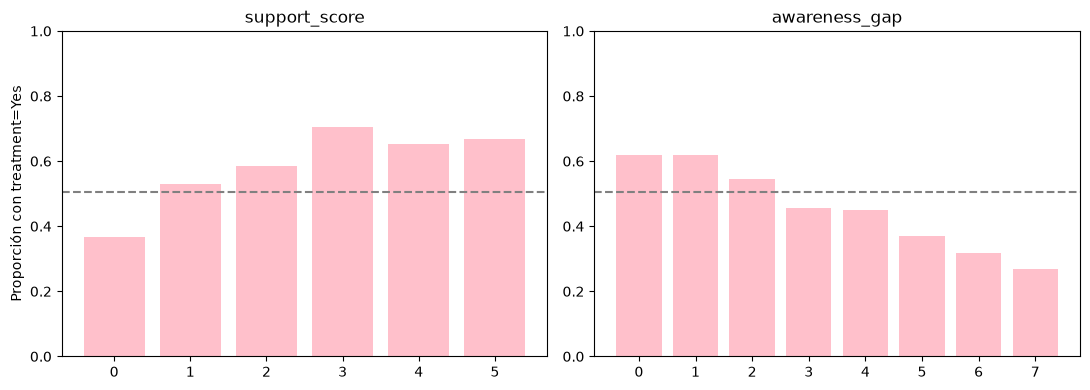

In [44]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4))
indices = ["support_score", "awareness_gap"]

for i in range(2):
    col = indices[i]
    tasa = (df_feat["treatment"] == "Yes").groupby(df_feat[col]).mean()
    ejes[i].bar(tasa.index.astype(str), tasa.values, color="Pink")
    ejes[i].axhline(0.506, linestyle="--", color="gray")
    ejes[i].set_ylim(0, 1)
    ejes[i].set_title(col)
ejes[0].set_ylabel("Proporción con treatment=Yes")
plt.tight_layout()
plt.show()

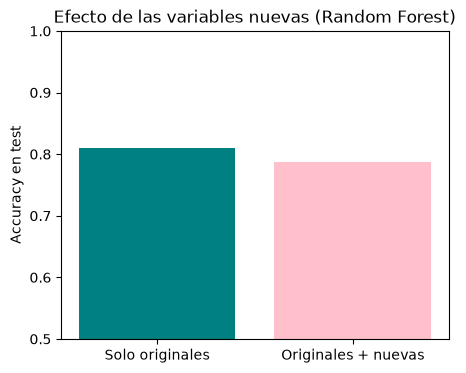

In [45]:
y = (df_feat["treatment"] == "Yes").astype(int)

X1 = pd.get_dummies(df_limpio.drop(columns=["treatment"]))
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.25, random_state=42, stratify=y)
modelo1 = RandomForestClassifier(n_estimators=200, random_state=42)
modelo1.fit(X1_train, y_train)
acc_sin = modelo1.score(X1_test, y_test)

X2 = pd.get_dummies(df_feat.drop(columns=["treatment", "age_group"]))
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)
modelo2 = RandomForestClassifier(n_estimators=200, random_state=42)
modelo2.fit(X2_train, y_train)
acc_con = modelo2.score(X2_test, y_test)

plt.figure(figsize=(5, 4))
plt.bar(["Solo originales", "Originales + nuevas"], [acc_sin, acc_con], color=["Teal", "Pink"])
plt.ylim(0.5, 1)
plt.ylabel("Accuracy en test")
plt.title("Efecto de las variables nuevas (Random Forest)")
plt.show()

La grafica compara el accuracy del Random Forest entrenado solo con las variables originales (0.81) contra uno entrenado con las variables originales mas las variables extraidas (0.79). Ambos modelos superan por mucho el azar (0.50), pero las variables nuevas no mejoraron el rendimiento, la diferencia de aproximadamente 2.3 puntos equivale a unas 7 personas del conjunto de prueba y cae dentro del margen de variacion esperable al usar una sola division train/test, por lo que no se considera concluyente. Esto es razonable porque los indices (support_score, awareness_gap) resumen informacion que ya estaba en las columnas originales, así que el modelo no recibe datos realmente nuevos. El beneficio de la tecnica no es predictivo sino interpretativo, permite resumir 5 a 7 preguntas en una sola variable facil de explicar.

# 4. Reducción de dimensionalidad (PCA)

Al convertir el texto a columnas, el dataset pasa de 27 columnas a más de 70, y muchas están relacionadas entre sí (por ejemplo `benefits_Yes` con `care_options_Yes`). Reducir dimensiones sirve para:
1. Ver los datos de mejor manera.
2. Quitar redundancia conservando la mayor parte de la información.

- PCA: combina columnas en componentes nuevos; permite ver cuánta varianza se conserva.

In [46]:
X = pd.get_dummies(df_feat.drop(columns=["treatment", "age_group"]))
X_escalado = StandardScaler().fit_transform(X)
print("Dimensiones originales:", X.shape[1])

pca_completo = PCA()
pca_completo.fit(X_escalado)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

n90 = (varianza_acumulada < 0.90).sum() + 1
n95 = (varianza_acumulada < 0.95).sum() + 1
print("Componentes para 90 % de varianza:", n90)
print("Componentes para 95 % de varianza:", n95)

puntos_pca = PCA(n_components=2).fit_transform(X_escalado)

Dimensiones originales: 74
Componentes para 90 % de varianza: 39
Componentes para 95 % de varianza: 44


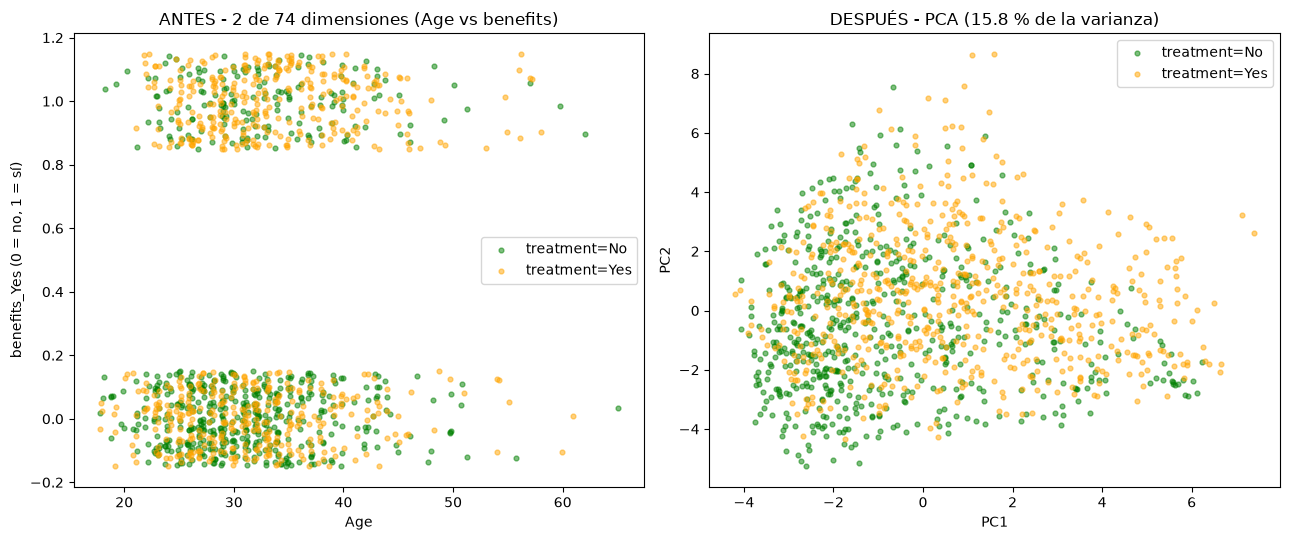

In [47]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5))
si = (df_feat["treatment"] == "Yes").values
no = ~si

edad = X["Age"].values + np.random.uniform(-0.3, 0.3, len(X))
benefits = X["benefits_Yes"].values + np.random.uniform(-0.15, 0.15, len(X))
ejes[0].scatter(edad[no], benefits[no], s=12, alpha=0.5, color="Green", label="treatment=No")
ejes[0].scatter(edad[si], benefits[si], s=12, alpha=0.5, color="Orange", label="treatment=Yes")
ejes[0].set_title("ANTES - 2 de " + str(X.shape[1]) + " dimensiones (Age vs benefits)")
ejes[0].set_xlabel("Age")
ejes[0].set_ylabel("benefits_Yes (0 = no, 1 = sí)")

ejes[1].scatter(puntos_pca[no, 0], puntos_pca[no, 1], s=12, alpha=0.5, color="Green", label="treatment=No")
ejes[1].scatter(puntos_pca[si, 0], puntos_pca[si, 1], s=12, alpha=0.5, color="Orange", label="treatment=Yes")
porcentaje = pca_completo.explained_variance_ratio_[:2].sum() * 100
ejes[1].set_title("DESPUÉS - PCA (" + str(round(porcentaje, 1)) + " % de la varianza)")
ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")

for eje in ejes:
    eje.legend()
plt.tight_layout()
plt.show()


- Con 2 componentes solo se conserva una pequeña parte de la varianza (15.8%), por eso la nube se ve mezclada. Aun así, PCA resume todas las columnas, mientras que "ANTES" solo muestra 2 al azar.
- Hay redundancia: se necesitan 39 componentes para conservar el 90 % de la varianza (de 74 columnas). Además, PCA conserva varianza, no información sobre `treatment`, por eso en 2 dimensiones los dos grupos no se separan.

# 5. Selección de características

PCA mezcla las columnas y ya no se sabe que significa cada componente. La seleccion en cambio se queda con columnas originales, asi que sirve para saber que preguntas de la encuesta importan de verdad, y quitar las que solo meten ruido.

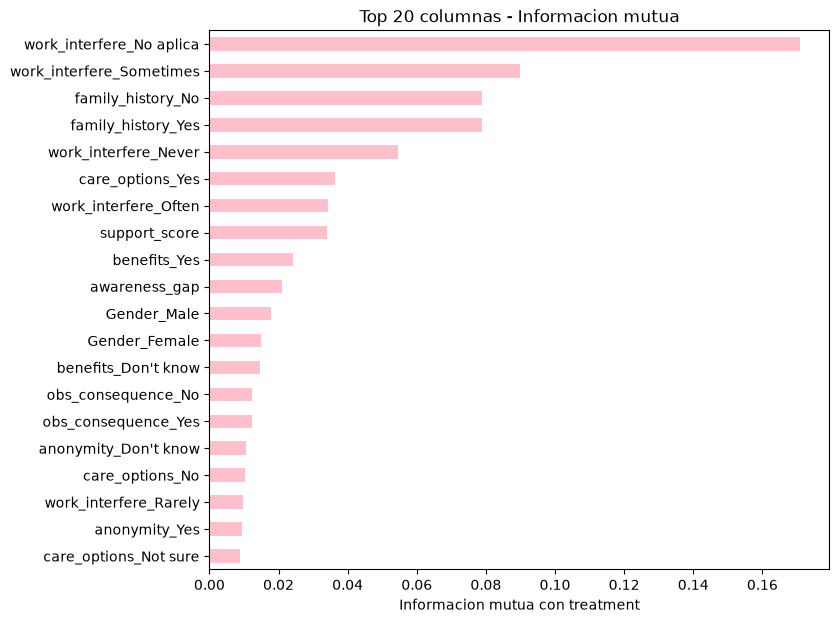

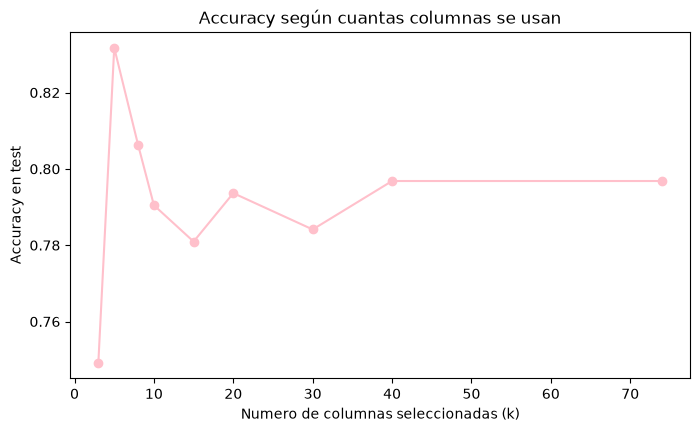

In [48]:
X = pd.get_dummies(df_feat.drop(columns=["treatment", "age_group"]))
y = (df_feat["treatment"] == "Yes").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

es_discreta = (X_train.columns != "Age")

info = mutual_info_classif(X_train, y_train, discrete_features=es_discreta, random_state=42)
info = pd.Series(info, index=X_train.columns).sort_values(ascending=False)


info.head(20)[::-1].plot.barh(figsize=(8, 7), color="Pink")
plt.xlabel("Informacion mutua con treatment")
plt.title("Top 20 columnas - Informacion mutua")
plt.show()


lista_k = [3, 5, 8, 10, 15, 20, 30, 40, X.shape[1]]
precisiones = []
for k in lista_k:
    mejores = list(info.index[:k])                  
    modelo = RandomForestClassifier(n_estimators=200, random_state=42)
    modelo.fit(X_train[mejores], y_train)
    precisiones.append(modelo.score(X_test[mejores], y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(lista_k, precisiones, marker="o", color="Pink")
plt.xlabel("Numero de columnas seleccionadas (k)")
plt.ylabel("Accuracy en test")
plt.title("Accuracy según cuantas columnas se usan")
plt.show()

En la grafica "Top 20 columnas - Informacion mutua" las columnas mas relacionadas con treatment vienen casi todas de dos preguntas: work_interfere (4 de las 7 primeras columnas, con work_interfere_No aplica en primer lugar con 0.171) y family_history (0.079 en sus dos categorias). Despues aparecen care_options_Yes, benefits_Yes y, de las variables extraídas en la técnica 3, support_score (0.034) y awareness_gap (0.021), ambas dentro del top 10. Esto coincide con el EDA, donde esas mismas variables mostraban las mayores diferencias en el porcentaje de tratamiento.

La grafica "Accuracy segun cuantas columnas se usan" con solo 5 columnas (que vienen de 2 preguntas, work_interfere y family_history) el accuracy llega a 0.83, el mas alto de la curva. Con 3 columnas baja a 0.75, probablemente porque no alcanzan a capturar ambas preguntas. Entre 10 y 30 columnas se queda entre 0.78 y 0.79, y con 40 columnas y con las 74 es 0.80. Es decir, agregar columnas no mejora el modelo, las 5 mejores bastan y el resto aporta ruido o informacion repetida.


# Conclusion 

En esta practica se aplicaron cinco tecnicas de procesamiento al dataset Mental Health in Tech Survey y se comparo el antes y el despues de cada una. Estos son los resultados principales:

- **Limpieza de datos:** fue la tecnica mas importante. Se corrigieron 9 edades imposibles (fuera de 18 a 65), se agruparon las 49 formas de escribir `Gender` en 3 categorias, se eliminaron las columnas sin valor analitico y se imputaron los nulos, quedando el dataset con 24 columnas y sin valores faltantes. Sin este paso, cualquier estadistico o modelo habria estado distorsionado.
- **Aumento de datos:** se sobre muestrearon los grupos pequeños de `Gender` (`Female` paso de 251 a 496 y `Other` de 15 a 49) para darles mas peso. En `Female` la proporcion de tratamiento casi no cambio, en `Other` si vario, porque 15 personas reales son muy pocas para sacar conclusiones. Como las copias no aportan informacion nueva, esta tecnica corrige la representacion de los grupos pero no garantiza un mejor modelo.
- **Extraccion de caracteristicas:** se crearon `support_score`, `awareness_gap` y `age_group`. No mejoraron el accuracy (0.81 contra 0.79), pero resumen varias preguntas en una sola variable facil de interpretar, y `support_score` y `awareness_gap` aparecieron despues en el top 10 de la informacion mutua.
- **Reduccion de dimensionalidad:** al convertir el texto a columnas, el dataset paso a 74 dimensiones. PCA mostro que hay redundancia (39 componentes conservan el 90 % de la varianza), pero con 2 componentes solo se conserva el 15.8 % y los dos grupos de `treatment` no se separan. Sirve para visualizar y resumir, pero sus componentes no se pueden interpretar.
- **Seleccion de caracteristicas:** fue la tecnica mas efectiva para este dataset. Con solo 5 columnas (provenientes de `work_interfere` y `family_history`) el accuracy llego a 0.83, frente a 0.80 con las 74, y además las columnas siguen siendo interpretables.

En conjunto, el hallazgo mas importante es que, para predecir si una persona ha buscado tratamiento, importan sobre todo dos preguntas: si su condicion interfiere con el trabajo y si tiene historial familiar. Esto coincidio en el EDA, en la extraccion de caracteristicas y en la seleccion, y es una señal confiable porque varias tecnicas distintas llegaron a lo mismo.

**Limitaciones:** Los modelos se evaluaron con una sola division train/test de 315 personas, por lo que diferencias de 2 o 3 puntos de accuracy son ruido, una mejora podria ser utilizar validacion cruzada para mejorar el muestreo de los datos. `work_interfere` solo se pregunta a quien ya tiene una condicion, asi que casi anticipa `treatment`. Los datos son de una encuesta voluntaria de 2014, principalmente de EE. UU., Reino Unido y Canada, por lo que los resultados no se pueden generalizar a toda la industria.

# Referencias

ifeel. (s.f.). Importancia de la salud mental en el sector tecnológico: un caso de éxito. ifeel. https://ifeelonline.com/es/salud-laboral/salud-mental-sector-tecnologico/

WebMD Health Services. (s.f.). Workplace mental health statistics by industry. WebMD Health Services. https://www.webmdhealthservices.com/blog/workplace-mental-health-statistics-by-industry/

Mind Share Partners. (2025). 2025 mental health at work report. Mind Share Partners. https://www.mindsharepartners.org/2025-mental-health-at-work-report

# Declaracion de uso de la IA

Para esta practica se utilizo la inteligencia artificial Anthropic Claude como herramienta de asistencia para la revision, edicion y mejora del formato de texto asi como el apoyo en la toma de sugerencias para la parte del codigo y la correccion de errores.